In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

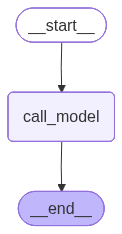

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Dilip."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Dilip.


'Hello Dilip, nice to meet you! How can I assist you today?'

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 40
Hi, my name is Dilip.
Hello Dilip, nice to meet you! How can I assist you today?
I am learning LangGraph.


"That's great! LangGraph is an artificial intelligence programming language that can be used to create chatbots and virtual assistants. If you have any questions or need help with anything specific, feel free to ask. I'm here to help!"

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 117
Hi, my name is Dilip.
Hello Dilip, nice to meet you! How can I assist you today?
I am learning LangGraph.
That's great! LangGraph is an artificial intelligence programming language that can be used to create chatbots and virtual assistants. If you have any questions or need help with anything specific, feel free to ask. I'm here to help!
Can you explain short term memory?


'Short-term memory, also known as working memory, is a temporary storage system that holds and manipulates information for a brief period of time. It is the part of memory where information is actively processed, organized, and used to guide behavior and decision-making in the immediate moment. Short-term memory typically has a limited capacity, holding a small amount of information (usually around 7 items) for a short duration (usually around 20-30 seconds) before either transferring it to long-term memory or forgetting it. It plays a crucial role in tasks like problem-solving, decision-making, reasoning, and learning new information.'

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


"I'm sorry, I do not have that information. Would you like me to refer to you by a specific name during our conversation?"

In [13]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Dilip.
------------------------------------------------------------------------------------------------------------------------
Hello Dilip, nice to meet you! How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's great! LangGraph is an artificial intelligence programming language that can be used to create chatbots and virtual assistants. If you have any questions or need help with anything specific, feel free to ask. I'm here to help!
------------------------------------------------------------------------------------------------------------------------
Can you explain short term memory?
------------------------------------------------------------------------------------------------------------------------
Short-term memory, a